 # Supernova distances and redshifts (part 1)

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np
import pylab as plt
from matplotlib import pyplot as plt

In [3]:
from astropy.cosmology import LambdaCDM

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

data are SN redshifts and distance modulus (with homoscedastic errors)

Quick visualization

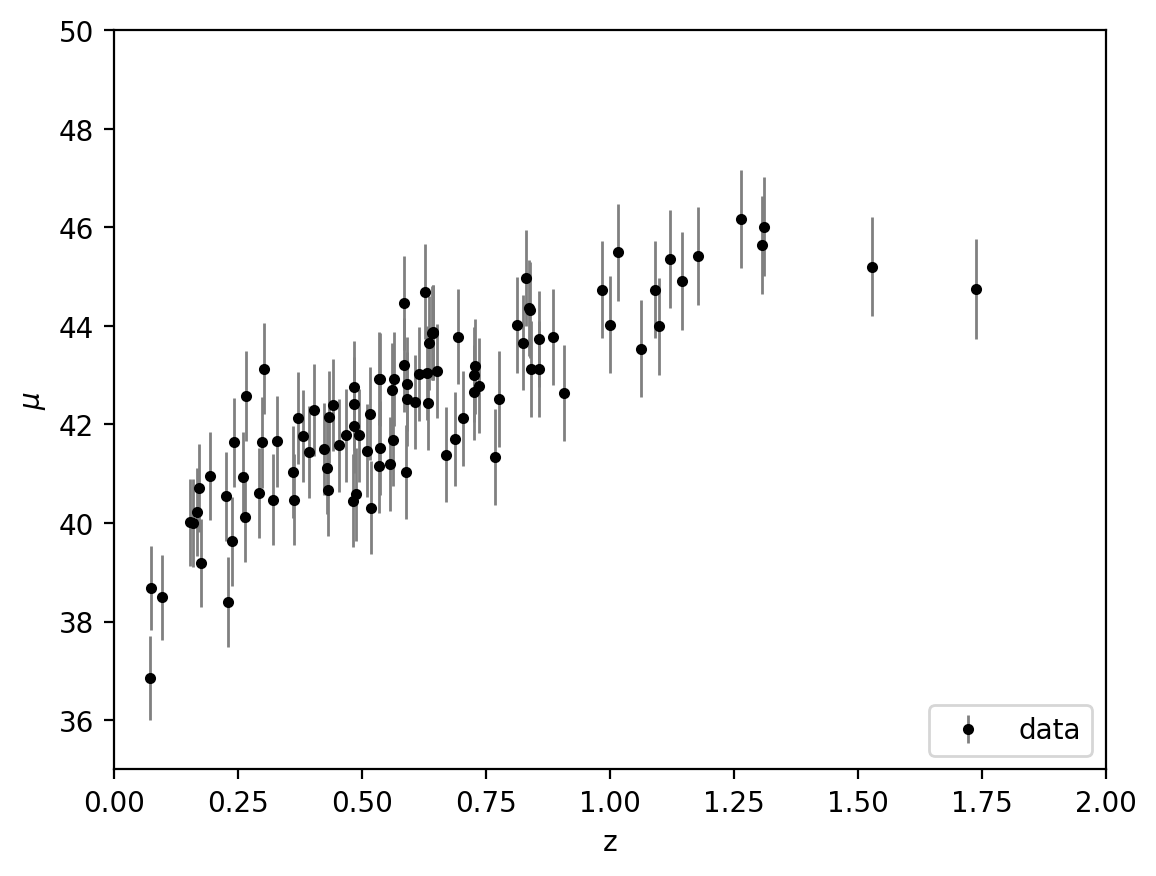

In [4]:
from astroML.datasets import generate_mu_z

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [5]:
x = z_sample.reshape(-1,1)
y = mu_sample
dy = dmu

# Linear Regression

In [6]:
from sklearn.base import BaseEstimator
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge

!!!

Couldn't import astroML LinearRegression nor PolynomialRegression, so I had to copy the source code from astroML website

In [7]:
#  Basis functions
def gaussian_basis(X, mu, sigma):
    """Gaussian Basis function

    Parameters
    ----------
    X : array_like
        input data: shape = (n_samples, n_features)
    mu : array_like
        means of bases, shape = (n_bases, n_features)
    sigma : float or array_like
        must broadcast to shape of mu

    Returns
    -------
    Xg : ndarray
        shape = (n_samples, n_bases)
    """
    X = np.asarray(X)
    mu = np.atleast_2d(mu)
    sigma = np.atleast_2d(sigma)

    n_samples, n_features = X.shape

    if mu.shape[1] != n_features:
        raise ValueError('shape of mu must match shape of X')

    r = (((X[:, None, :] - mu) / sigma) ** 2).sum(2)
    Xg = np.exp(-0.5 * r)
    Xg *= 1. / np.sqrt(2 * np.pi) / sigma.prod(1)

    return Xg

In [8]:
class LinearRegression(BaseEstimator):
    """Simple Linear Regression with errors in y

    This is a stripped-down version of sklearn.linear_model.LinearRegression
    which can correctly accounts for errors in the y variable

    Parameters
    ----------
    fit_intercept : bool (optional)
        if True (default) then fit the intercept of the data
    regularization : string (optional)
        ['l1'|'l2'|'none'] Use L1 (Lasso) or L2 (Ridge) regression
    kwds: dict
        additional keyword arguments passed to sklearn estimators:
        LinearRegression, Lasso (L1), or Ridge (L2)

    Notes
    -----
    This implementation may be compared to that in
    sklearn.linear_model.LinearRegression.
    The difference is that here errors are
    """
    _regressors = {'none': LinearRegression,
                   'l1': Lasso,
                   'l2': Ridge}

    def __init__(self, fit_intercept=True, regularization='none', kwds=None):
        if regularization.lower() not in ['l1', 'l2', 'none']:
            raise ValueError("regularization='{}' not recognized"
                             "".format(regularization))
        self.fit_intercept = fit_intercept
        self.regularization = regularization
        self.kwds = kwds


    def _transform_X(self, X):
        X = np.asarray(X)
        if self.fit_intercept:
            X = np.hstack([np.ones([X.shape[0], 1]), X])
        return X

    @staticmethod
    def _scale_by_error(X, y, y_error=1):
        """Scale regression by error on y"""
        X = np.atleast_2d(X)
        y = np.asarray(y)
        y_error = np.asarray(y_error)

        assert X.ndim == 2
        assert y.ndim == 1
        assert X.shape[0] == y.shape[0]

        if y_error.ndim == 0:
            return X / y_error, y / y_error

        elif y_error.ndim == 1:
            assert y_error.shape == y.shape
            X_out, y_out = X / y_error[:, None], y / y_error

        elif y_error.ndim == 2:
            assert y_error.shape == (y.size, y.size)
            evals, evecs = np.linalg.eigh(y_error)
            X_out = np.dot(evecs * (evals ** -0.5),
                           np.dot(evecs.T, X))
            y_out = np.dot(evecs * (evals ** -0.5),
                           np.dot(evecs.T, y))
        else:
            raise ValueError("shape of y_error does not match that of y")

        return X_out, y_out

    def _choose_regressor(self):
        model = self._regressors.get(self.regularization.lower(), None)
        if model is None:
            raise ValueError("regularization='{}' unrecognized"
                             "".format(self.regularization))
        return model

    def fit(self, X, y, y_error=1):
        kwds = {}
        if self.kwds is not None:
            kwds.update(self.kwds)
        kwds['fit_intercept'] = False

        model = self._choose_regressor()
        self.clf_ = model(**kwds)

        X = self._transform_X(X)
        X, y = self._scale_by_error(X, y, y_error)

        self.clf_.fit(X, y)
        return self

    def predict(self, X):
        X = self._transform_X(X)
        return self.clf_.predict(X)

    @property
    def coef_(self):
        return self.clf_.coef_

Fit model to data and visualize

In [9]:
model = LinearRegression()
model.fit(x, y, dy)

print(model.coef_)

[39.48384602  4.76438865]


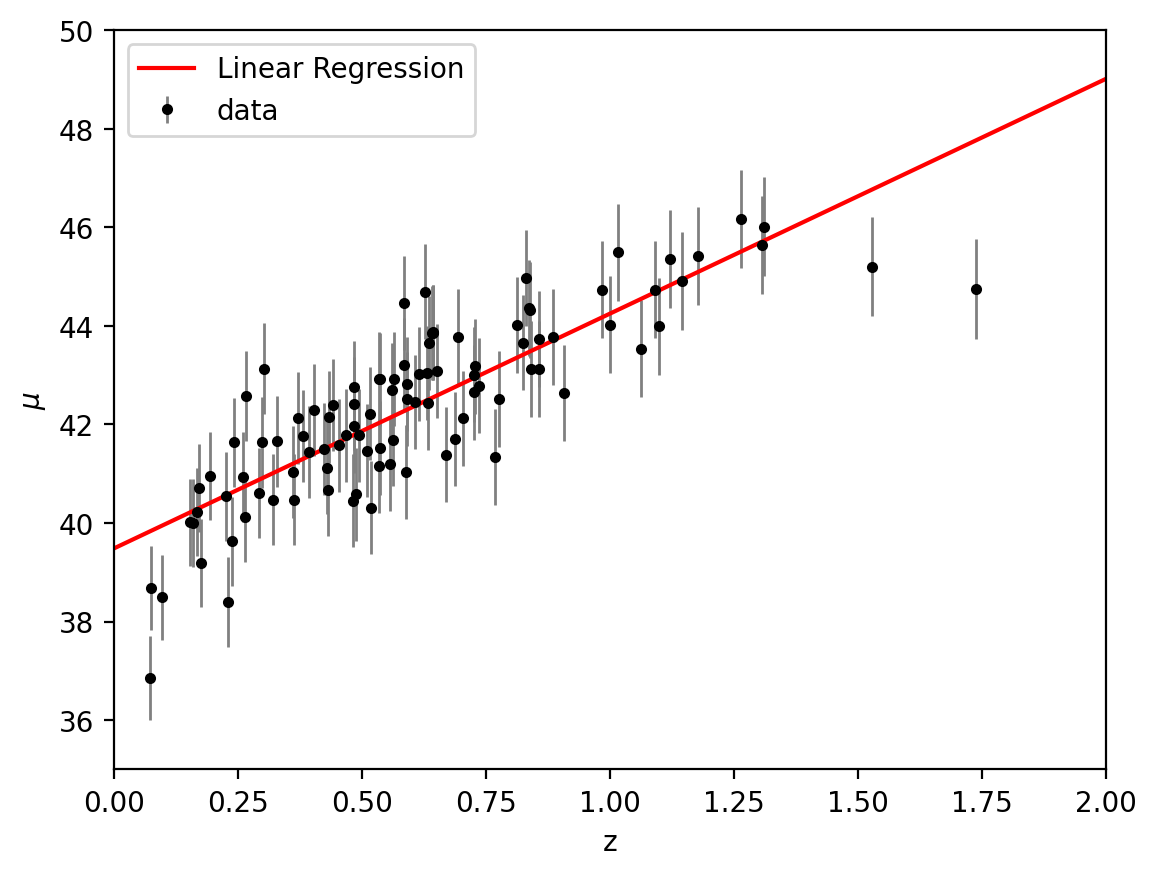

In [10]:
x_grid = np.linspace(0,2,1000).reshape(-1,1)
y_pred=model.predict(x_grid)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(x_grid, y_pred, "r", label="Linear Regression")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend()
plt.show()

doesn't seem like a very good fit: for regions with less datapoints (lower z, higher z), the model evaluated on unseen redshifts doesn't capture the behavior of observed distance modulus

# Polynomial Regression

In [11]:
class PolynomialRegression(LinearRegression):
    """Polynomial Regression with errors in y

    Parameters
    ----------
    degree : int
        degree of the polynomial.
    interaction_only : bool (optional)
        If true, only interaction features are produced: features that are
        products of at most ``degree`` *distinct* input features (so not
        ``x[1] ** 2``, ``x[0] * x[2] ** 3``, etc.).
    fit_intercept : bool (optional)
        if True (default) then fit the intercept of the data
    regularization : string (optional)
        ['l1'|'l2'|'none'] Use L1 (Lasso) or L2 (Ridge) regression
    kwds: dict
        additional keyword arguments passed to sklearn estimators:
        LinearRegression, Lasso (L1), or Ridge (L2)
    """
    def __init__(self, degree=1, interaction_only=False,
                 fit_intercept=True,
                 regularization='none', kwds=None):
        self.degree = degree
        self.interaction_only = interaction_only
        LinearRegression.__init__(self, fit_intercept, regularization, kwds)


    def _transform_X(self, X):
        trans = PolynomialFeatures(degree=self.degree,
                                   interaction_only=self.interaction_only,
                                   include_bias=self.fit_intercept)
        return trans.fit_transform(X)

Fitting with different degree polynomials and visualizing

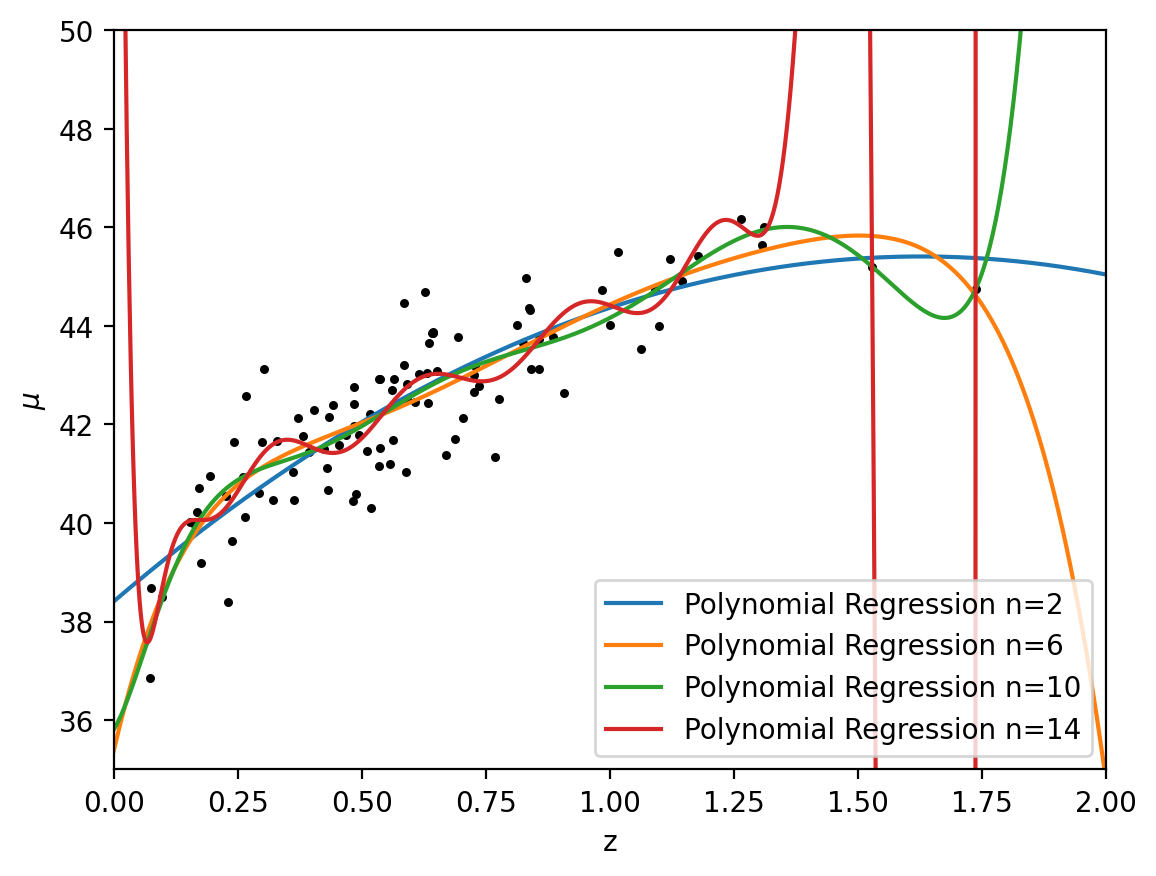

In [12]:
for n in np.arange(1,16)[1::4]:
    model = PolynomialRegression(n)
    model.fit(x, y, dy)
    y_pred = model.predict(x_grid)
    plt.plot(x_grid, y_pred,label='Polynomial Regression n='+str(n))

plt.scatter(z_sample, mu_sample, color='black', s=5)
#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

N=14 PolynomialRegression model (evaluated on unseen redshifts) shows an oscillatory behavior and the vertical trends al lower and higher z: possible overfitting

N = 8

In [13]:
model = PolynomialRegression(8)
model.fit(x,y,dy)

PolynomialRegression(degree=8)

In [14]:
y_pred=model.predict(x_grid)

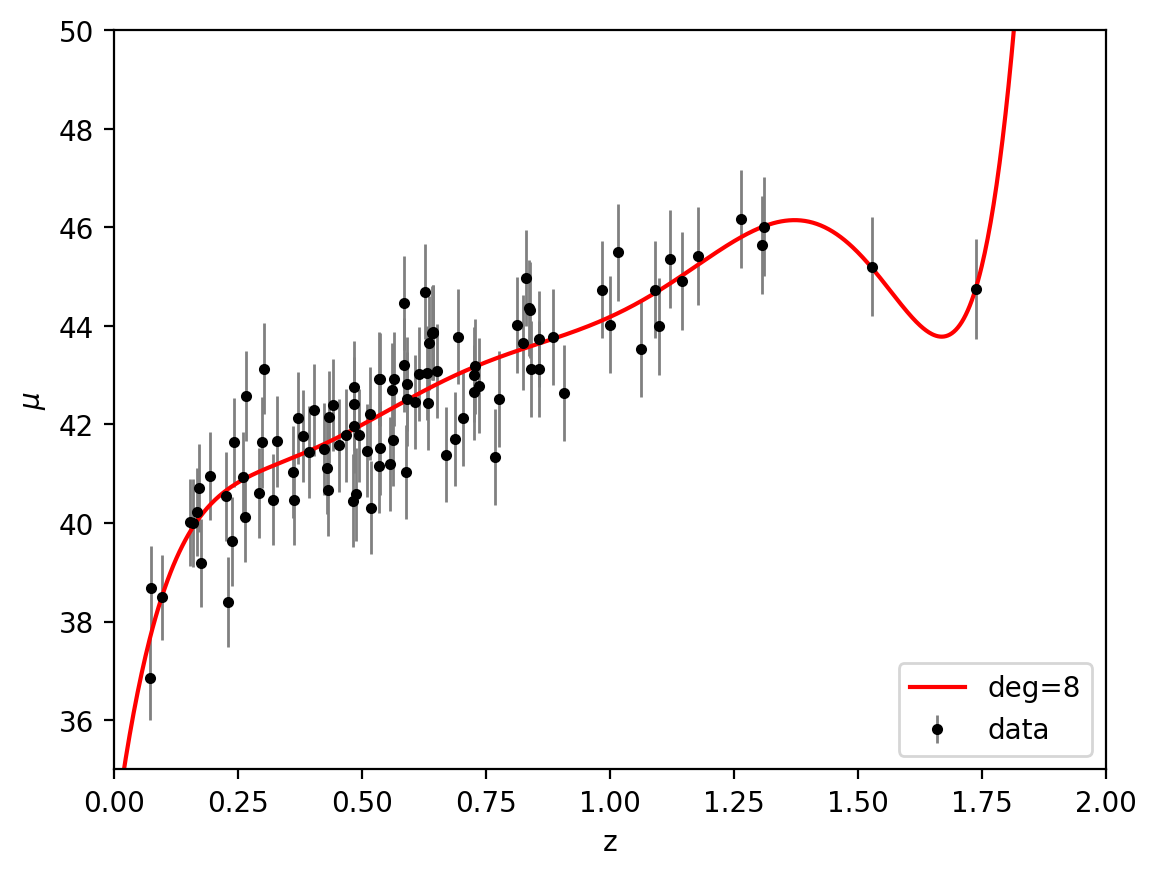

In [15]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x_grid,y_pred, c='red', label='deg=8')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

N = 2

In [16]:
model = PolynomialRegression(2)
model.fit(x,y,dy)

PolynomialRegression(degree=2)

In [17]:
y_pred=model.predict(x_grid)

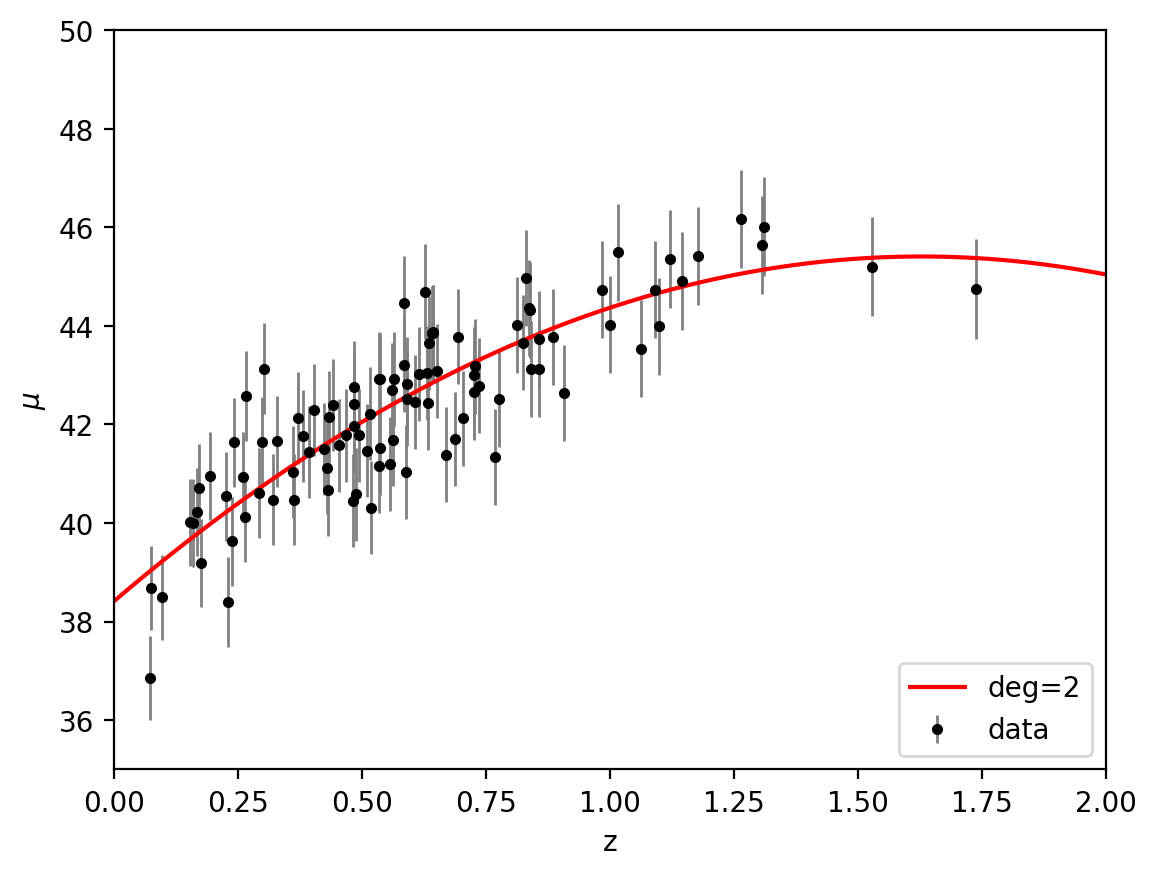

In [18]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x_grid,y_pred, c='red',label='deg=2')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

# Train-validation split

Now I will split my dataset into training set and validation set: then I will fit the training data and predict on the validation set. This will be used to estimate training and validation errors. 

In [19]:
X_train, X_validation, y_train, y_validation, dy_train, dy_validation = train_test_split(x, y, dy, test_size=0.3, random_state=42)

Polynomial regression with different degrees, compute errors and plot them to determine the degree of the best fit model

Polynomial Regression n= 1 1.0485115996674979 0.8238924629073962
Polynomial Regression n= 2 0.9385359114081153 0.8351995054159926
Polynomial Regression n= 3 0.9383899628086961 0.8354111725641474
Polynomial Regression n= 4 0.9024072712440716 0.8095703348999908
Polynomial Regression n= 5 0.8924469328124864 0.8143335829739328
Polynomial Regression n= 6 0.890502817194987 0.8113859054713991
Polynomial Regression n= 7 0.8699559684825426 0.8163407910202957
Polynomial Regression n= 8 0.8695867558752143 0.8211204495391577
Polynomial Regression n= 9 0.8696086089174789 0.8218234526955969
Polynomial Regression n= 10 0.8666795023371139 0.846377734873724
Polynomial Regression n= 11 0.8624581177705724 0.8513668728049187
Polynomial Regression n= 12 0.8558274201610684 0.819159757005468
Polynomial Regression n= 13 0.8528955457426771 0.8247869265163832
Polynomial Regression n= 14 0.8407659993948631 0.8121594656861812
Polynomial Regression n= 15 0.8383792832807809 0.8271900735321285
Polynomial Regression 

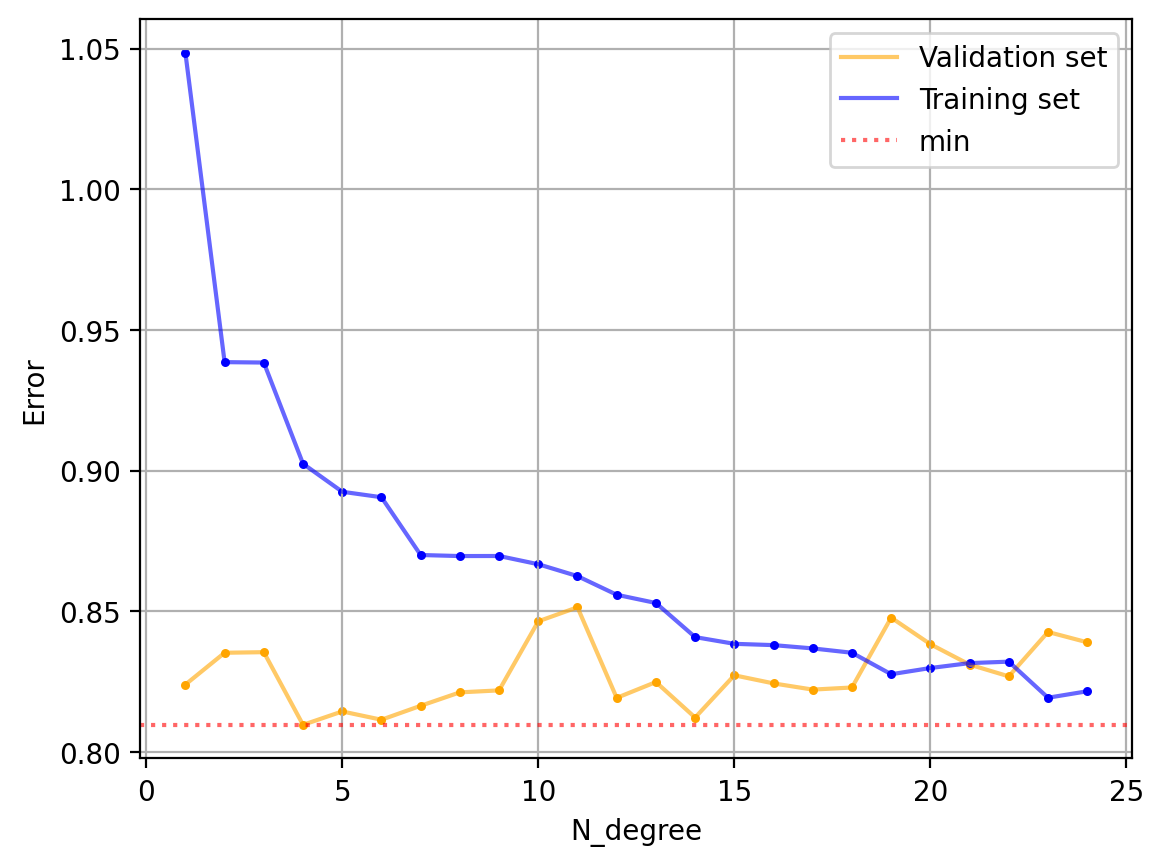

In [20]:
nrange = np.arange(1,25)

etrain, etest= [], []
for n in nrange:
    clf = PolynomialRegression(n)
    clf.fit(X_train, y_train,dy_train)

    error_train=np.sqrt( np.sum(( y_train - clf.predict(X_train) )**2) / len(X_train) )
    error_val=np.sqrt( np.sum(( y_validation - clf.predict(X_validation) )**2) / len(X_validation) )
    
    print("Polynomial Regression n=",n, error_train, error_val)
    etrain.append(error_train)
    etest.append(error_val)

plt.plot(nrange,etest, label='Validation set', alpha=0.6, color='orange')
plt.plot(nrange,etrain, label='Training set', alpha=0.6, color='blue')
plt.scatter(nrange,etest, color='orange', s=5)
plt.scatter(nrange,etrain, color='blue', s=5)
plt.axhline(min(etest), label='min', alpha=0.6, ls='dotted', color='red')

plt.xlabel('N_degree')
plt.ylabel('Error')
plt.grid()
plt.legend()

When the validation error is minimized, the model fitted is the best one

In [21]:
print("Best fit with N =",nrange[np.argmin(etest)])

Best fit with N = 4


BEST FIT visualization

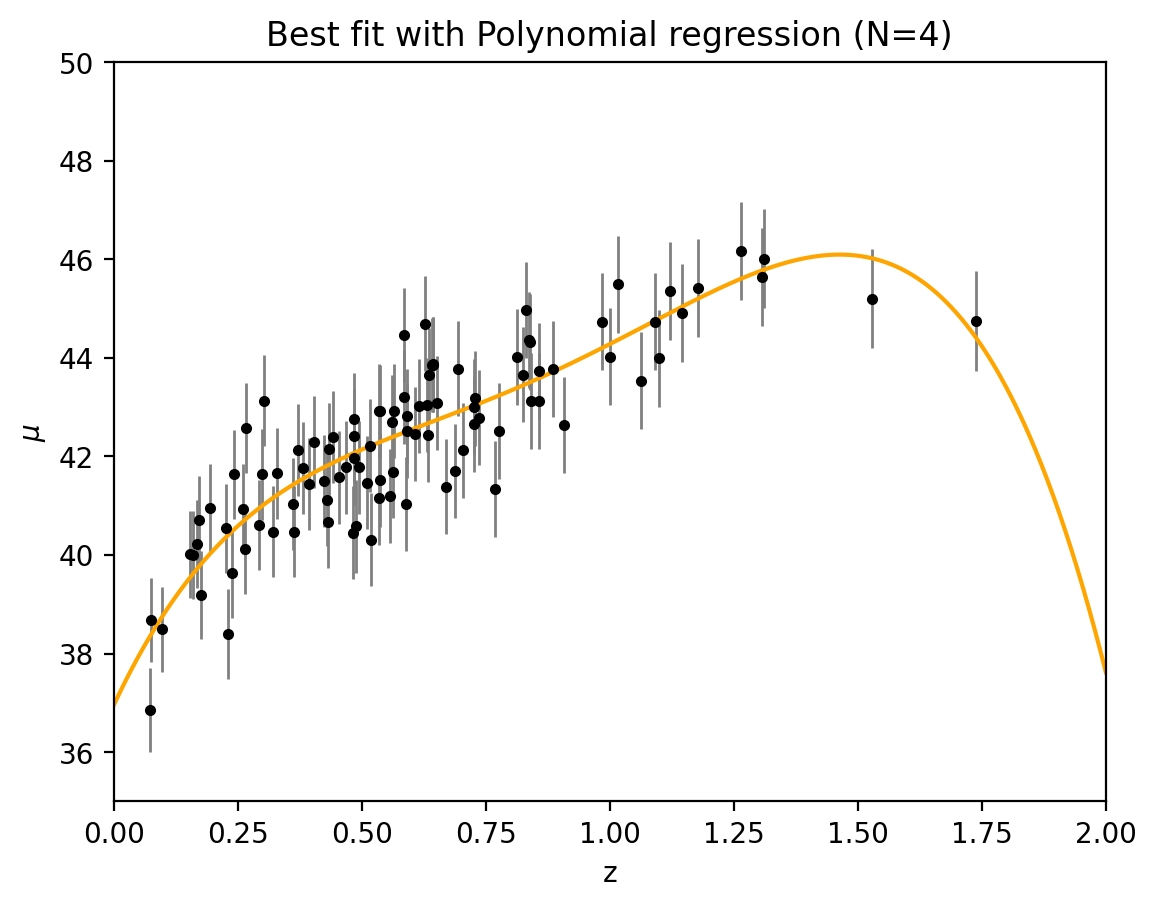

In [22]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

model = PolynomialRegression(4)
model.fit(x, y, dy)
y_pred = model.predict(x_grid)
plt.plot(x_grid, y_pred, color='orange')

plt.title('Best fit with Polynomial regression (N=4)')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

The fitted model at higer z could be influenced by the very last two points of the dataset (which fall into training set and could affect the result of the regression). When evaluating the model on unseed redshifts (orange curve), the trend at higher redshift is decreasing steeply.

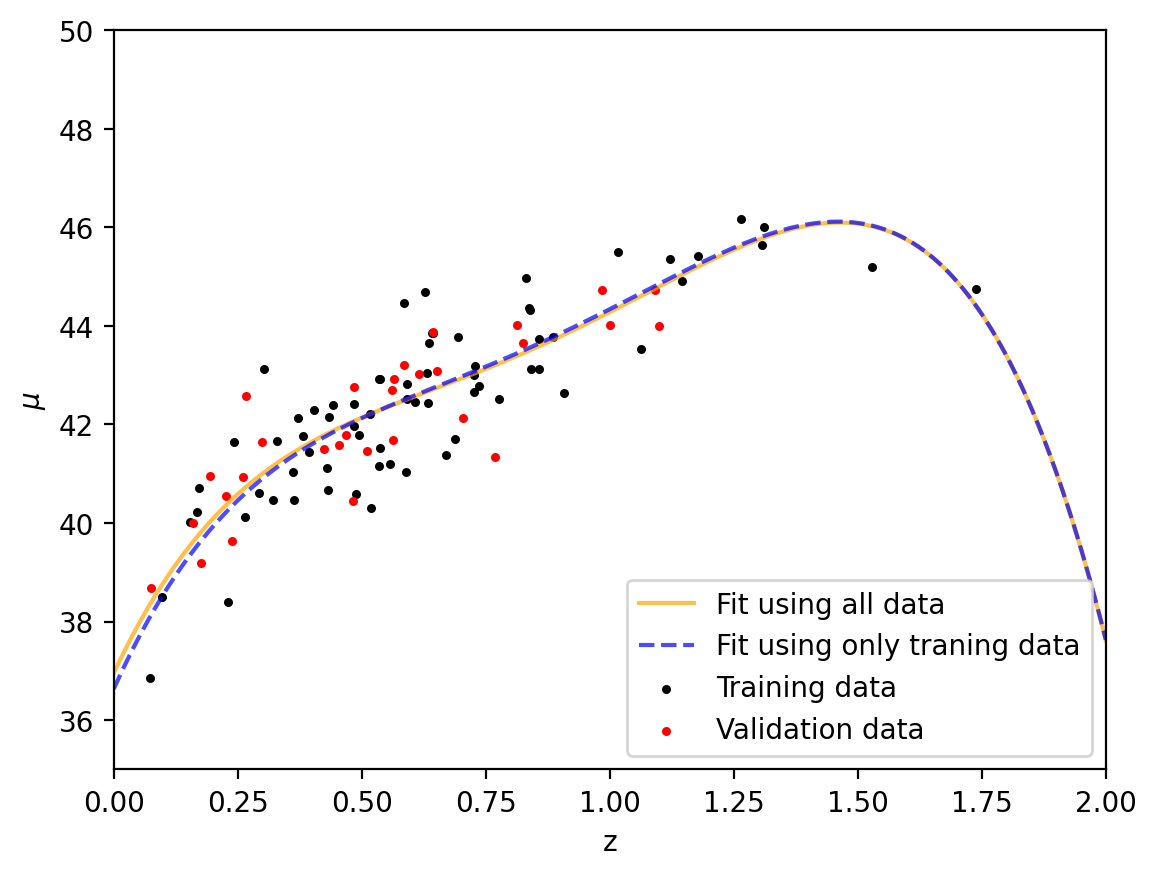

In [23]:
plt.plot(x_grid, y_pred, color='orange', alpha=0.7, label='Fit using all data')

model.fit(X_train, y_train,dy_train)
mu_fit = model.predict(x_grid)

plt.plot(x_grid, mu_fit, color='blue', alpha=0.7, ls='dashed', label='Fit using only traning data')

plt.scatter(X_train, y_train, s=5, color='black', label='Training data')
plt.scatter(X_validation, y_validation, s=5, color='red', label='Validation data')

#plt.errorbar(X_train, y_train, dy_train, fmt='.k', ecolor='gray', lw=1,label='Training data')
#plt.errorbar(X_validation, y_validation, dy_validation, fmt='.r', ecolor='red', lw=1, label='Validation data')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend(loc='lower right');

If we fit using all datapoints as opposed to just the subset of training data we obtain slightly different curves at lower z. As we can see here, the last points are in the training set, maybe cross validation could improve the performance of PolynomialRegression

# cross-validation

In [24]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)

def fit_and_err_kf(model):
    err_train = []
    err_cv = []
    
    for train, cv in kf.split(X_train):
        
        x_train, x_val = X_train[train], X_train[cv]
        
        y_t, y_val = y_train[train], y_train[cv]
        
        dy_t, dy_val = dy_train[train], dy_train[cv]
        
        model.fit(x_train, y_t, dy_t)

        err_train.append(np.sqrt( np.sum(( y_t - model.predict(x_train) )**2) / len(x_train) ))
        err_cv.append(np.sqrt( np.sum(( y_val - model.predict(x_val) )**2) / len(x_val) ))
        
    error_train = np.mean(err_train)
    error_val = np.mean(err_cv)
    
    return error_train, error_val

Best degree: 5


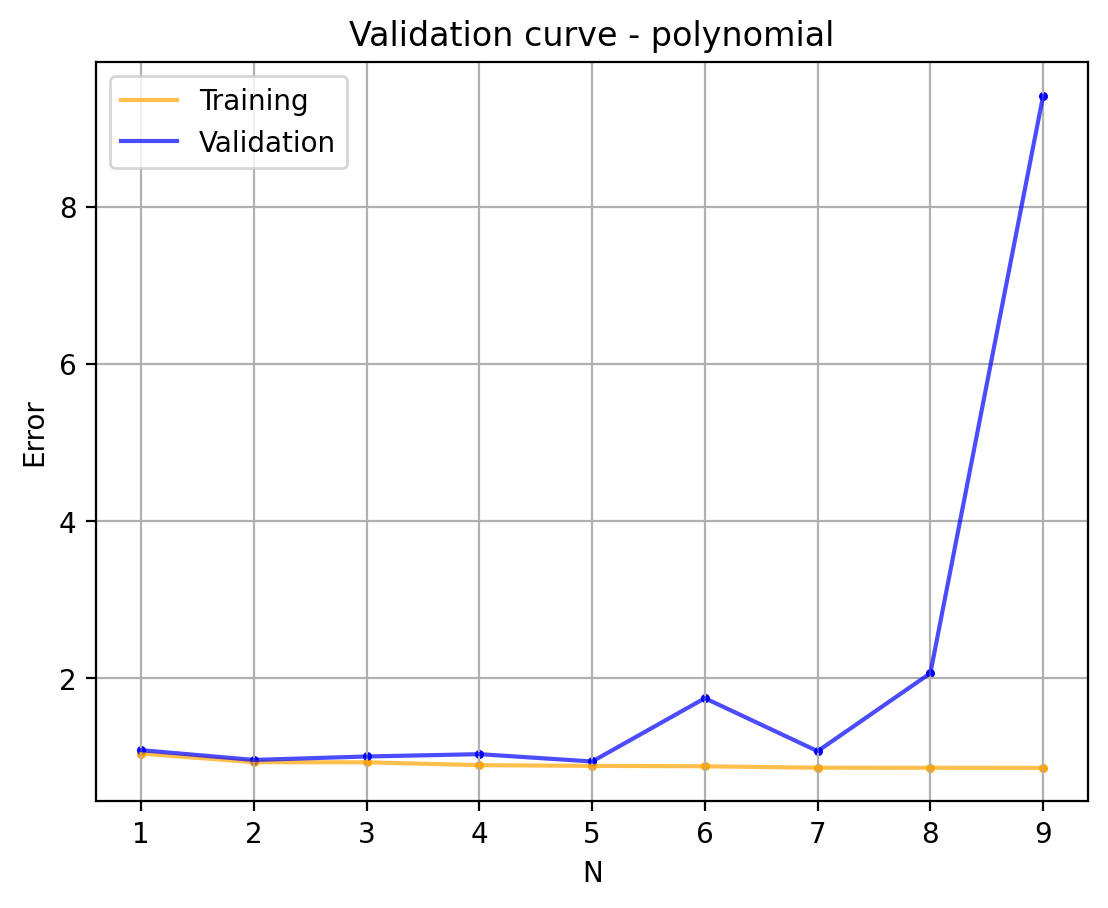

In [25]:
N = np.arange(1,10)

train_error = np.zeros(N.size)
validation_error = np.zeros(N.size)

for i, n in enumerate(N):
    model = PolynomialRegression(n)
    train_error[i], validation_error[i] = fit_and_err_kf(model)

best = N[np.argmin(validation_error)]

print("Best degree: " + str( best ))

plt.plot(N, train_error, color='orange', alpha=0.7, label='Training')
plt.plot(N, validation_error, color='blue', alpha=0.7, label='Validation')

plt.scatter(N, train_error, color='orange',s=5)
plt.scatter(N, validation_error, color='blue', s=5)

plt.title('Validation curve - polynomial')
plt.xlabel("N")
plt.ylabel("Error")
plt.grid()
plt.legend()
plt.show()

with cross validation (10 k-folds) the best fit is for N=5, where the validation error is minimized

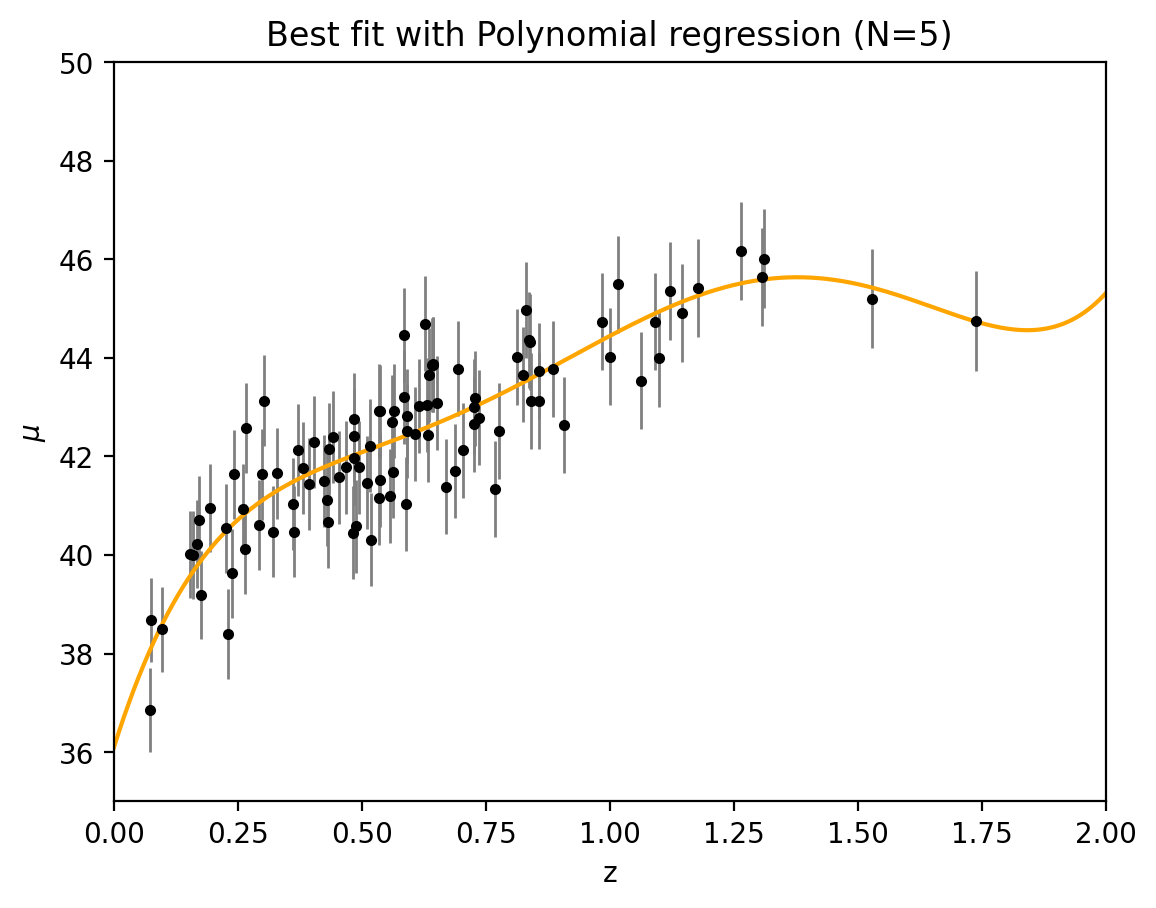

In [26]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

model = PolynomialRegression(best)
model.fit(x, y, dy)
y_pred = model.predict(x_grid)
plt.plot(x_grid, y_pred, color='orange')

plt.title('Best fit with Polynomial regression (N=5)')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()